**<h1>Linear Regression</h1>**

In [1]:
%matplotlib inline
import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

**<h2>Minibatch stochastic gradient descent</h2>**

### **1.Minibatch Stochastic Gradient Descent (SGD)--Introduction**

These equations describe how we iteratively update the model parameters (weights $\mathbf{w}$ and bias $b$) to minimize error using a small batch of data.

#### **1. The Variables & Dimensions**
| Symbol | Meaning | Dimension | Notes |
| :--- | :--- | :--- | :--- |
| $\mathbf{w}$ | **Weights** | $d \times 1$ | The vector of learnable parameters (one per feature). |
| $b$ | **Bias** | $1 \times 1$ | The learnable intercept/offset (scalar). |
| $\mathbf{x}^{(i)}$ | **Input Features** | $d \times 1$ | The features for a single example $i$ in the batch. |
| $y^{(i)}$ | **True Label** | $1 \times 1$ | The actual target value for example $i$. |
| $\eta$ | **Learning Rate** | Scalar | A hyperparameter (e.g., 0.01) controlling step size. |
| $|\mathcal{B}|$ | **Batch Size** | Scalar | The number of examples used in this specific update step. |

#### **2. The Error Term**
The term inside the parenthesis is the **Prediction Error** (Scalar):
$$(\underbrace{\mathbf{w}^\top \mathbf{x}^{(i)} + b}_{\text{Prediction } \hat{y}} - \underbrace{y^{(i)}}_{\text{Actual}})$$

#### **3. The Update Logic**
* **Weight Update ($\mathbf{w}$):**
    $$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \text{AverageGradient}$$
    The error is multiplied by $\mathbf{x}^{(i)}$ because features with larger values contribute more to the prediction (via the Chain Rule).
    * *Dimension Check:* $(d \times 1) \leftarrow (d \times 1) - \text{scalar} \cdot (d \times 1)$

* **Bias Update ($b$):**
    $$b \leftarrow b - \eta \cdot \text{AverageError}$$
    The error is summed directly because the bias always has a coefficient of 1 (independent of feature values).
    * *Dimension Check:* Scalar $\leftarrow$ Scalar - Scalar

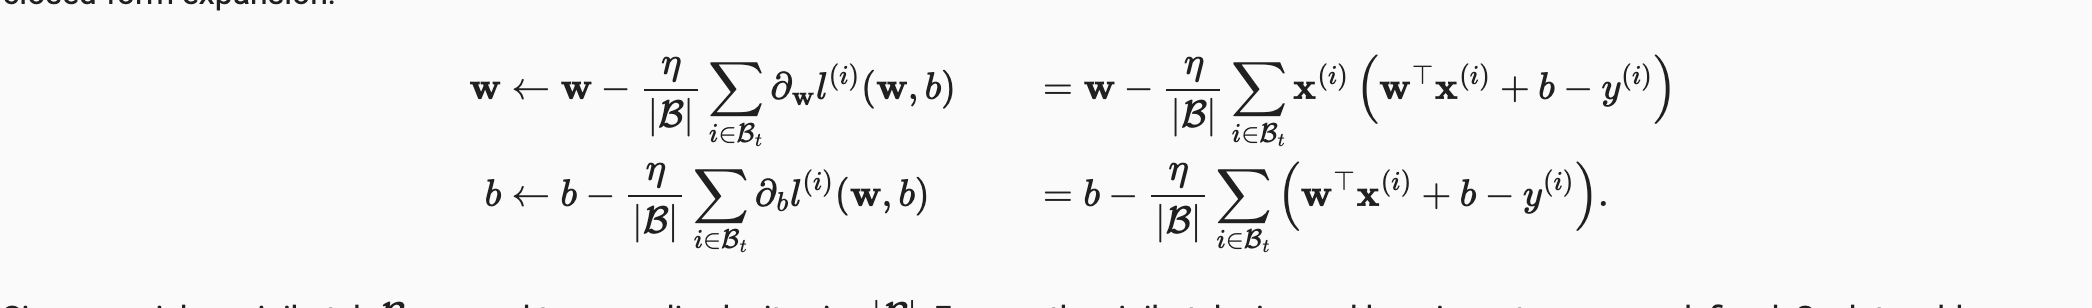

### **2.Vectorization for Speed: A Benchmark**

This code demonstrates why we avoid Python loops in machine learning and instead use **Vectorization** (fast linear algebra libraries).

#### **1. The Experiment Setup**
We initialize two vectors, $\mathbf{a}$ and $\mathbf{b}$, each containing **10,000 elements** (all ones). We then measure the time it takes to add them together ($\mathbf{a} + \mathbf{b}$) using two different methods.

#### **2. The Comparison**

| Method | Code Logic | Time Taken | Verdict |
| :--- | :--- | :--- | :--- |
| **1. Python For-Loop** | Iterates through each index `i` individually to add `a[i] + b[i]`. | **0.17802 sec** | **Slow.** Python overhead slows down every single addition. |
| **2. Vectorization** | Uses the `+` operator (`d = a + b`), which offloads the math to optimized C/C++ libraries. | **0.00036 sec** | **Fast.** The operation is parallelized and optimized. |

#### **3. Key Takeaway**
The vectorized approach is **orders of magnitude faster** (in this case, roughly **500x faster**). In Deep Learning, where we process millions of parameters, vectorization is not optional—it is required for training to finish in a reasonable time.

In [2]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)
c=torch.zeros(n)
t=time.time()
for i in range(n):
    c[i]=a[i]+b[i]
f'{time.time() - t:.5f} sec'

'0.06167 sec'

In [3]:
t=time.time()
d=a+b
f'{time.time() - t:.5f} sec'

'0.00035 sec'

### **3.The Normal Distribution and Squared Loss**

### **Maximum Likelihood Estimation (MLE)**

This section provides the mathematical justification for *why* we use "Mean Squared Error" (MSE) in Linear Regression. It connects probability theory with linear algebra.

#### **1. The Code: Visualizing Noise**
The code block defines a `normal` function to plot Gaussian (Bell) curves.
* **Goal:** To visualize the assumption that real-world data is just the "Perfect Line" + "Normal Noise."
* **Result:** The graph shows how changing $\mu$ shifts the center, and increasing $\sigma$ makes the curve flatter (representing more uncertain/noisy data).

#### **2. The Math: From Probability to Least Squares**
We want to find weights $\mathbf{w}$ that maximize the probability (Likelihood) of seeing our specific dataset.

* **The Assumption (Eq 3.1.13):**
  $$y = \mathbf{w}^\top \mathbf{x} + b + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$
  Data = Model + Gaussian Noise.

* **Probability of ONE Example (Eq 3.1.14):**
  $$P(y|\mathbf{x}) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{1}{2\sigma^2}(y - \mathbf{w}^\top \mathbf{x} - b)^2\right)$$
  Given our model weights $\mathbf{w}$, what is the probability of seeing this specific data point $y$?
  
* **The Likelihood (Eq 3.1.15):**
  $$P(\mathbf{y}|\mathbf{X}) = \prod_{i=1}^n p(y^{(i)}|\mathbf{x}^{(i)})$$
  The probability of the entire dataset is the *product* of the probabilities of each individual point.

* **The Log-Likelihood (Eq 3.1.16):**
  To avoid numerical underflow (multiplying tiny numbers) and simplify calculus, we take the **Logarithm**:
  $$-\log P(\mathbf{y}|\mathbf{X}) = \sum_{i=1}^n \frac{1}{2\sigma^2} (y^{(i)} - \mathbf{w}^\top \mathbf{x}^{(i)} - b)^2 + C$$

#### **3. The Conclusion**
Notice that the final equation contains the **Squared Error** term: $(y - \hat{y})^2$.
* Maximizing the Likelihood of the data is mathematically identical to **Minimizing the Squared Error**.
* This proves that Least Squares is the statistically optimal method for Linear Regression under Gaussian noise.

$$ p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{1}{2\sigma^2}(x-\mu)^2\right) $$

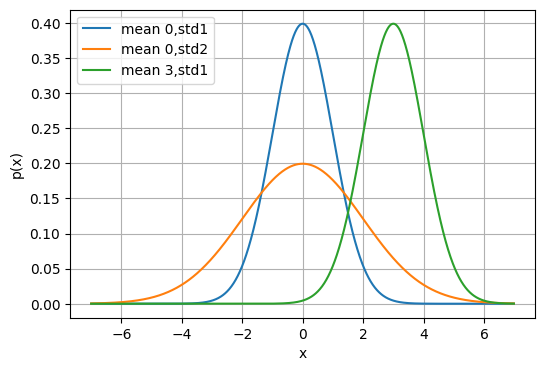

In [5]:
#function defining the normal distribution
def normal(x,mu,sigma):
    p=1/math.sqrt(2*math.pi*sigma**2)
    return p*np.exp(-0.5*(x-mu)**2/sigma**2)
#visualize the normal distributjon
x=np.arange(-7,7,0.01)
params=[(0,1),(0,2),(3,1)]
# 3. Plotting using Matplotlib
plt.figure(figsize=(6, 4)) # Set the size of the plot
for mu,sigma in params:
    plt.plot(x,normal(x,mu,sigma),label=f'mean {mu},std{sigma}')
# 4. Add Labels and Legend
plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.grid(True) # Optional: Adds a grid for easier reading
plt.show()